#Loading Dataset from collab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Paste your file path here (example path shown)
file_path = '/content/drive/MyDrive/Copy of das_data.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the data frame
print(df.head())

          1          2          3          4          5         6          7  \
0  1.674872 -17.868902 -32.525712 -36.215309 -24.668963 -1.000943  22.846576   
1  1.572164 -15.799018 -29.193468 -33.031543 -22.897632 -1.166239  21.182723   
2  1.726060 -14.156271 -26.676981 -30.682274 -21.756598 -1.706114  19.424014   
3  1.846338 -12.472263 -23.731443 -27.227335 -18.923658 -0.474753  18.914022   
4  2.070068  -5.870659 -12.820797 -15.466961  -9.819278  4.068052  19.628227   

           8          9         10  ...       5992       5993       5994  \
0  33.130308  25.579567  10.290069  ...  40.198558  57.188372  45.367615   
1  31.047602  24.077721   9.645518  ...  36.598079  51.940050  40.170576   
2  29.254792  23.367924  10.251154  ...  33.260127  45.746236  33.196569   
3  27.902782  22.496171  10.597904  ...  27.484918  38.165221  25.933356   
4  27.652234  24.227005  15.115581  ...  17.718550  24.224009  10.981315   

        5995       5996       5997       5998       5999      

In [ ]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


## Seperating channel strain-values from channel labels


In [ ]:
# df: your original dataframe
# time columns assumed to be all except 'Target'

time_cols = [c for c in df.columns if c != "Target"]

X = df[time_cols].values    # shape: (N_channels, T)
y = df["Target"].values    # shape: (N_channels,)


In [ ]:
X = X.astype(np.float32)
y = y.astype(np.float32)


In [ ]:
def downsample(x, factor=10):
    return x[:, ::factor]

X = downsample(X, factor=10)
print(X.shape)  # (N_channels, T_down)



(6000, 600)


## 80-20 Train-Test split


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Function for channel wise normalization


In [ ]:
class DASDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]

        # per-channel normalization
        mean = x.mean()
        std = x.std() + 1e-6
        x = (x - mean) / std

        x = torch.tensor(x).unsqueeze(0)  # (1, T)
        y = torch.tensor(self.y[idx])

        return x, y


## Setting up the datapipeline

In [ ]:
batch_size = 32

train_ds = DASDataset(X_train, y_train)
val_ds   = DASDataset(X_val, y_val)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


## 1-D CNN architecture

In [ ]:
class DAS1DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1)
        )

    def forward(self, x, return_emb=False):
        x = self.features(x)
        x = self.pool(x).squeeze(-1)
        emb = x
        out = self.classifier(x)
        if return_emb:
            return out, emb
        return out


In [ ]:
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor([pos_weight], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

model = DAS1DCNN().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x).squeeze()
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x).squeeze()
        loss = criterion(logits, y)
        total_loss += loss.item()

    return total_loss / len(loader)


## Training loop


In [ ]:
train_losses = []
val_losses = []

epochs = 10
best_val = np.inf
patience = 8
counter = 0

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train 0.6359 | Val 0.4573
Epoch 02 | Train 0.1988 | Val 2.3879
Epoch 03 | Train 0.1053 | Val 0.2425
Epoch 04 | Train 0.0510 | Val 0.0631
Epoch 05 | Train 0.0653 | Val 0.0810
Epoch 06 | Train 0.0361 | Val 0.0193
Epoch 07 | Train 0.0317 | Val 0.0149
Epoch 08 | Train 0.0247 | Val 0.2357
Epoch 09 | Train 0.0710 | Val 0.0622
Epoch 10 | Train 0.0221 | Val 0.0080


## training and validation loss as no of epochs increases


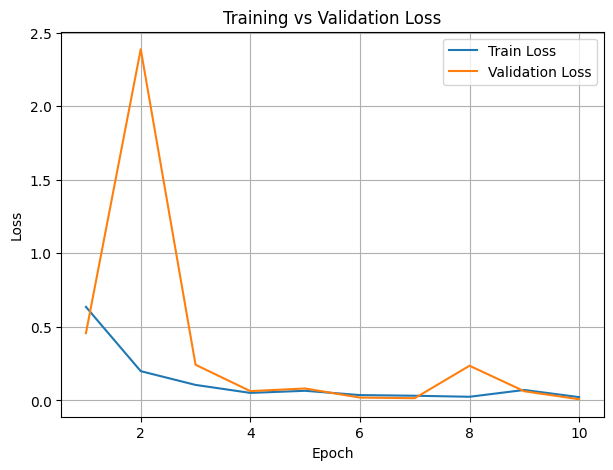

In [ ]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_ran, train_losses, label="Train Loss")
plt.plot(epochs_ran, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()


DAS1DCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(15,), stride=(2,), padding=(7,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 32, kernel_size=(15,), stride=(2,), padding=(7,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(32, 64, kernel_size=(11,), stride=(2,), padding=(5,))
    (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,))
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
@torch.no_grad()
def predict_probs(model, X):
    probs = []

    for i in range(len(X)):
        x = X[i]
        x = (x - x.mean()) / (x.std() + 1e-6)
        x = torch.tensor(x).unsqueeze(0).unsqueeze(0).to(device)

        logit = model(x)
        prob = torch.sigmoid(logit).item()
        probs.append(prob)

    return np.array(probs)


probs = predict_probs(model, X)

print(probs)

[1.66264144e-05 1.35700993e-05 9.78266144e-06 ... 9.98557389e-01
 9.98428643e-01 9.97379065e-01]


## Model accuracy

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# Convert probabilities to binary predictions using a threshold of 0.5
# If prob > 0.5, predict 1, else predict 0
predictions = (probs > 0.5).astype(int)

# Calculate the accuracy score
accuracy = accuracy_score(y, predictions)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9990


In [ ]:
suspect_pos = np.where((y == 1) & (probs < 0.3))[0]
suspect_neg = np.where((y == 0) & (probs > 0.7))[0]

print("Suspicious positives:", len(suspect_pos))
print("Suspicious negatives:", len(suspect_neg))


Suspicious positives: 2
Suspicious negatives: 0


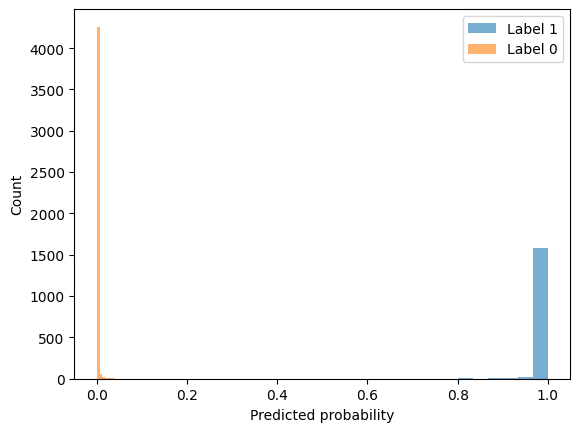

In [ ]:
import matplotlib.pyplot as plt

plt.hist(probs[y == 1], bins=30, alpha=0.6, label="Label 1")
plt.hist(probs[y == 0], bins=30, alpha=0.6, label="Label 0")
plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()


In [ ]:
np.unique(np.round(probs, 3))


array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
       0.018, 0.019, 0.02 , 0.022, 0.023, 0.024, 0.025, 0.026, 0.027,
       0.028, 0.029, 0.03 , 0.031, 0.038, 0.04 , 0.043, 0.052, 0.053,
       0.062, 0.065, 0.067, 0.071, 0.077, 0.09 , 0.102, 0.173, 0.246,
       0.332, 0.348, 0.403, 0.418, 0.602, 0.64 , 0.66 , 0.803, 0.817,
       0.825, 0.841, 0.842, 0.872, 0.878, 0.881, 0.882, 0.888, 0.89 ,
       0.896, 0.9  , 0.912, 0.917, 0.921, 0.924, 0.927, 0.936, 0.939,
       0.941, 0.943, 0.949, 0.952, 0.953, 0.954, 0.955, 0.956, 0.957,
       0.958, 0.963, 0.965, 0.966, 0.968, 0.971, 0.972, 0.973, 0.974,
       0.975, 0.977, 0.978, 0.979, 0.98 , 0.981, 0.982, 0.983, 0.984,
       0.985, 0.986, 0.987, 0.988, 0.989, 0.99 , 0.991, 0.992, 0.993,
       0.994, 0.995, 0.996, 0.997, 0.998, 0.999, 1.   ])

In [ ]:
print(probs[y == 1].min(), probs[y == 1].max())
print(probs[y == 0].min(), probs[y == 0].max())


0.0010343637550249696 1.0
1.630282020492757e-10 0.17313550412654877


In [ ]:
suspect_pos = np.where((y == 1) & (probs < 0.55))[0]
suspect_neg = np.where((y == 0) & (probs > 0.45))[0]

print(len(suspect_pos), len(suspect_neg))


6 0


In [ ]:
pos_thresh = np.percentile(probs[y == 1], 15)   # weakest positives
neg_thresh = np.percentile(probs[y == 0], 85)   # strongest negatives

suspect_pos = np.where((y == 1) & (probs <= pos_thresh))[0]
suspect_neg = np.where((y == 0) & (probs >= neg_thresh))[0]


## Predicted probability as a function of channel

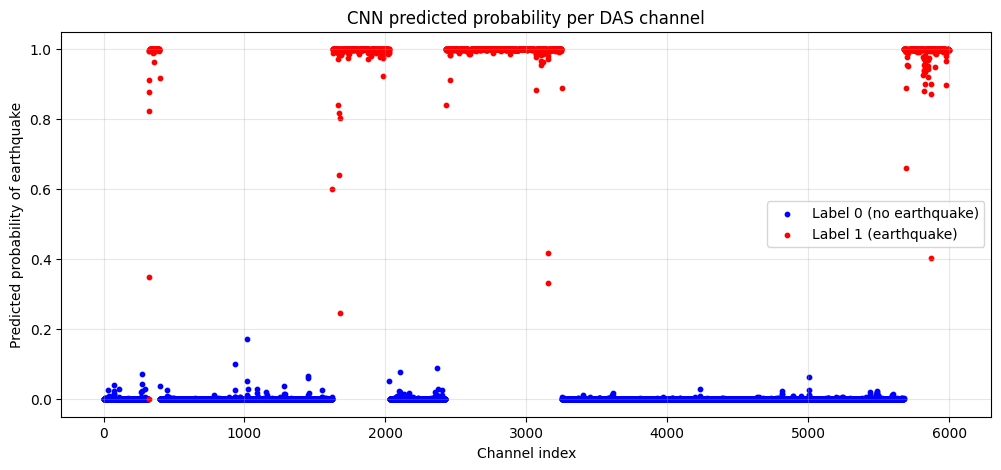

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# probs: the array of predicted probabilities per channel (already computed)
# y: the original labels (0 or 1)

channels = np.arange(len(probs))  # channel index

plt.figure(figsize=(12, 5))

# Scatter plot: probability per channel
plt.scatter(channels[y==0], probs[y==0], color='blue', s=10, label='Label 0 (no earthquake)')
plt.scatter(channels[y==1], probs[y==1], color='red', s=10, label='Label 1 (earthquake)')

plt.xlabel("Channel index")
plt.ylabel("Predicted probability of earthquake")
plt.title("CNN predicted probability per DAS channel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
